In [1]:
!pip install torchinfo

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
from PIL import Image
from tqdm.notebook import tqdm
import psutil
import platform

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from itertools import cycle

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [4]:
data_dir = "/kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer"
output_dir = "/kaggle/working/processed-dataset"  
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoints_path, exist_ok=True)

train_batch = 32
test_batch = 16
total_class = 5 
learning_rate = 0.0001
decay = 1e-4
epoch = 100   
patience = 10


In [5]:
def load_data(root_dir):
    file_paths = []
    labels = []
    print(f"Scanning directory: {root_dir}...")
    
    if not os.path.exists(root_dir):
        print(f"ERROR: Directory not found: {root_dir}")
        return pd.DataFrame()

    classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    print(f"Detected classes: {classes}")

    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        for root, dirs, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                    file_paths.append(os.path.join(root, file))
                    labels.append(class_name)

    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    
    if not df.empty:
        df['filename_stem'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
        df = df.drop_duplicates(subset=['label', 'filename_stem']).drop(columns=['filename_stem'])

    print(f"Total images found: {len(df)}")
    return df

data = load_data(data_dir)

Scanning directory: /kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer...
Detected classes: ['cervix_koc', 'cervix_dyk', 'cervix_pab', 'cervix_sfi', 'cervix_mep']
Total images found: 25000


In [6]:
train_dataframe, temp_dataframe = train_test_split(data, test_size=0.30, stratify=data['label'], random_state=42)
validation_dataframe, test_dataframe = train_test_split(temp_dataframe, test_size=0.50, stratify=temp_dataframe['label'], random_state=42)

def data_preprocess(df, split_name, size=(224, 224), quality=100):
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    processed_file_paths = []

    print(f"Processing {split_name} images...")
    for idx, row in df.iterrows():
        label = row['label']
        label_dir = os.path.join(split_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        try:
            img = Image.open(row['file_path']).convert("RGB")  
            img = img.resize(size, Image.Resampling.LANCZOS)
            file_name = f"{idx}.jpg"
            save_path = os.path.join(label_dir, file_name)
            img.save(save_path, optimize=True, quality=quality)
            processed_file_paths.append(save_path)
        except Exception:
            processed_file_paths.append(row['file_path'])

    df['file_path'] = processed_file_paths
    return df

train_dataframe = data_preprocess(train_dataframe, "train")
validation_dataframe = data_preprocess(validation_dataframe, "val")
test_dataframe = data_preprocess(test_dataframe, "test")

Processing train images...
Processing val images...
Processing test images...


In [7]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = PIL.Image.open(row['file_path']).convert("RGB")
        label = self.label_map[row['label']]
        if self.transform:
            image = self.transform(image)
        return image, label


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(train_dataframe, transform=train_transform)
valid_dataset = ImageDataset(validation_dataframe, transform=val_test_transform)
test_dataset = ImageDataset(test_dataframe, transform=val_test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2)
validation_dataloader = DataLoader(valid_dataset, batch_size=test_batch, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2)

print("DataLoaders ready.")

DataLoaders ready.


In [9]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

In [10]:
class CervicalCancerNet_Attention(nn.Module):
    def __init__(self, num_classes):
        super(CervicalCancerNet_Attention, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.cbam1 = CBAM(32) 
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.cbam2 = CBAM(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.cbam3 = CBAM(128)

        # Block 4
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.cbam4 = CBAM(256)

        # Pooling
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        # --- Classifier ---
        self.flatten = nn.Flatten()
        # Input calculation: 224 -> 112 -> 56 -> 28 -> 14. 256 channels * 14 * 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.cbam1(x) # Apply Attention
        
        # Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.cbam2(x) # Apply Attention
        
        # Block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.cbam3(x) # Apply Attention
        
        # Block 4
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.cbam4(x) # Apply Attention
        
        # Classifier
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
model = CervicalCancerNet_Attention(total_class).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=decay)

print("Attention-Enhanced Model Initialized.")

Attention-Enhanced Model Initialized.


In [12]:
def train_attention_model(model, train_loader, val_loader, num_epochs, patience):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    start_time = time.time() 
    print("Starting Training...")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / total
        epoch_acc = correct / total
    
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / val_total
        val_epoch_acc = val_correct / val_total
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")
        
        # Early Stopping & Checkpointing
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"{checkpoints_path}/attention_model_best.pt")
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break
            
    training_time = time.time() - start_time
    print(f"\nTotal Training Duration: {training_time:.2f} seconds")
    return history, training_time

In [13]:
history, train_duration = train_attention_model(model, train_dataloader, validation_dataloader, epoch, patience)

Starting Training...


Epoch 1/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.5406 Acc: 0.7953 | Val Loss: 0.2001 Acc: 0.9400


Epoch 2/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.2287 Acc: 0.9183 | Val Loss: 0.1273 Acc: 0.9555


...

Epoch 44: Train Loss: 0.0138 Acc: 0.9955 | Val Loss: 0.0003 Acc: 1.0000


Epoch 45/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 45: Train Loss: 0.0068 Acc: 0.9979 | Val Loss: 0.0006 Acc: 1.0000


Epoch 46/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 46: Train Loss: 0.0099 Acc: 0.9967 | Val Loss: 0.0004 Acc: 1.0000
Early stopping triggered.

Total Training Duration: 3116.42 seconds


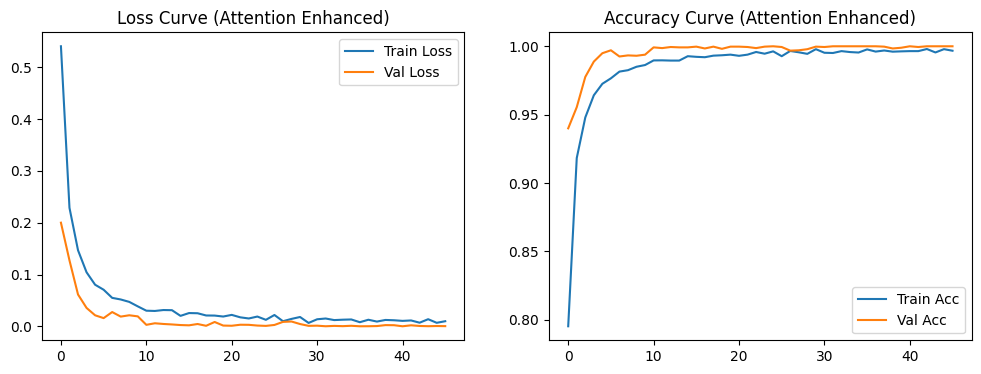

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Attention Enhanced)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve (Attention Enhanced)')
plt.legend()
plt.show()


Loading Best Model for Evaluation...


Evaluating:   0%|          | 0/235 [00:00<?, ?it/s]

Testing Duration: 5.81 seconds

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  cervix_dyk       1.00      1.00      1.00       750
  cervix_koc       1.00      1.00      1.00       750
  cervix_mep       1.00      1.00      1.00       750
  cervix_pab       1.00      1.00      1.00       750
  cervix_sfi       1.00      1.00      1.00       750

    accuracy                           1.00      3750
   macro avg       1.00      1.00      1.00      3750
weighted avg       1.00      1.00      1.00      3750



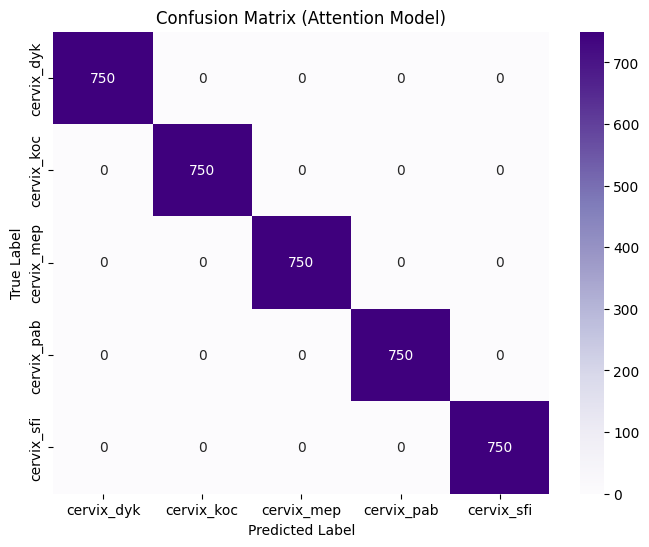


--- Class-wise Accuracy ---
cervix_dyk: 100.00%
cervix_koc: 100.00%
cervix_mep: 100.00%
cervix_pab: 100.00%
cervix_sfi: 100.00%

--- ROC Curves & AUC ---


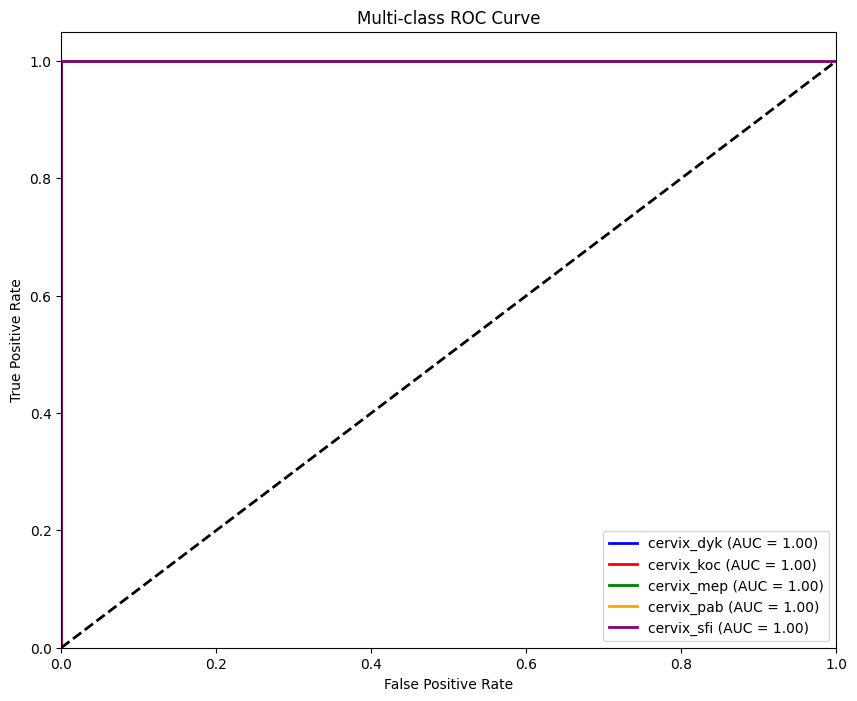

In [15]:
def evaluate_attention(loader, class_map):
    print("\nLoading Best Model for Evaluation...")
    model.load_state_dict(torch.load(f"{checkpoints_path}/attention_model_best.pt", map_location=device))
    model.eval()
    
    y_true = []
    y_pred = []
    y_probs = []
    
    start_test = time.time()
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Get probabilities for ROC
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            
    test_duration = time.time() - start_test
    print(f"Testing Duration: {test_duration:.2f} seconds")
    
    # Map indices back to class names
    idx_to_class = {v: k for k, v in class_map.items()}
    target_names = [idx_to_class[i] for i in range(len(class_map))]
    
    # 1. Classification Report (Precision, Recall, F1)
    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Attention Model)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # 3. Class Accuracy
    print("\n--- Class-wise Accuracy ---")
    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    for i, acc in enumerate(class_acc):
        print(f"{target_names[i]}: {acc*100:.2f}%")
        
    # 4. AUC and ROC Curve
    print("\n--- ROC Curves & AUC ---")
    y_true_bin = label_binarize(y_true, classes=range(len(target_names)))
    y_probs = np.array(y_probs)
    
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    
    for i, color in zip(range(len(target_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{target_names[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Run Evaluation
evaluate_attention(test_dataloader, train_dataset.label_map)

# Imports

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import os
import time
import numpy as np
import pandas as pd # Added for DataFrame manipulation
import matplotlib.pyplot as plt
import seaborn as sns # Used for Confusion Matrix visualization

from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, classification_report # Added classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# --- Configuration ---
data_dir = '/kaggle/input/cervical-cancer-largest-dataset-sipakmed'
train_batch_size = 32
val_test_batch_size = 32
num_workers = 2
num_epochs = 10
learning_rate = 0.001

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [23]:
class CervicalDataset(Dataset):
    def __init__(self, root_dir, transform=None, split_type='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.split_type = split_type
        self.image_paths = []
        self.labels = []
        self.label_map = {}

        print(f"Initializing CervicalDataset for split '{split_type}' from root_dir: {root_dir}")

        top_level_items = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        found_images_count = 0

        if not top_level_items:
             # Add logic for error handling/inference based on your environment
             pass

        for top_item in top_level_items:
            first_level_path = os.path.join(root_dir, top_item)
            nested_class_path = os.path.join(first_level_path, top_item)
            cropped_folder_path = os.path.join(nested_class_path, 'CROPPED')

            if os.path.isdir(cropped_folder_path):
                # print(f"Found CROPPED folder for class '{top_item}' at: {cropped_folder_path}")
                for img_name in os.listdir(cropped_folder_path):
                    if img_name.lower().endswith('.bmp'):
                        img_path = os.path.join(cropped_folder_path, img_name)
                        self.image_paths.append(img_path)
                        self.labels.append(top_item)
                        found_images_count += 1
            else:
                direct_cropped_path = os.path.join(first_level_path, 'CROPPED')
                if os.path.isdir(direct_cropped_path):
                    # print(f"WARNING: Found CROPPED directly under {first_level_path} (no nested class folder).")
                    for img_name in os.listdir(direct_cropped_path):
                        if img_name.lower().endswith('.bmp'):
                            img_path = os.path.join(direct_cropped_path, img_name)
                            self.image_paths.append(img_path)
                            self.labels.append(top_item)
                            found_images_count += 1

        if found_images_count == 0:
            raise ValueError(f"No .bmp images found in: {root_dir}.")

        # print(f"Total images found for split '{split_type}': {len(self.image_paths)}")

        unique_labels = sorted(list(set(self.labels)))
        self.label_map = {label: i for i, label in enumerate(unique_labels)}
        self.int_labels = [self.label_map[label] for label in self.labels]
        self.num_classes = len(self.label_map)

        print(f"Detected classes: {unique_labels}")
        print(f"Number of classes: {self.num_classes}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.int_labels[idx]
        return image, label

# --- Custom Dataset Class 2: Handles Pre-Split Data ---
class SplitDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels # Already integer labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, label

# --- Transformations ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet stats
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [25]:
# Check data directory
print(f"\nAttempting to load data from: {data_dir}")
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"The specified data_dir does not exist: {data_dir}. Please check the path.")

# Create a "master" dataset to get all paths and labels first
master_dataset = CervicalDataset(root_dir=data_dir, transform=None, split_type='master')
total_class = master_dataset.num_classes # Renamed for consistency with target format
class_names = list(master_dataset.label_map.keys())

print(f"\nMaster dataset size: {len(master_dataset)} images.")
print(f"Number of classes detected (total_class): {total_class}")

# Create DataFrame for paths and labels
df = pd.DataFrame({
    'file_path': master_dataset.image_paths,
    'label': master_dataset.int_labels # Using int labels for splitting
})

# Perform stratified train/validation/test split (70:15:15)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

# Extract paths and labels for datasets
train_paths, train_labels = train_df['file_path'].tolist(), train_df['label'].tolist()
val_paths, val_labels = val_df['file_path'].tolist(), val_df['label'].tolist()
test_paths, test_labels = test_df['file_path'].tolist(), test_df['label'].tolist()

print(f"Dataset split sizes: Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

# Create dataset instances for each split with their specific transforms
train_dataset = SplitDataset(train_paths, train_labels, data_transforms['train'])
val_dataset = SplitDataset(val_paths, val_labels, data_transforms['val'])
test_dataset = SplitDataset(test_paths, test_labels, data_transforms['test'])

# Create DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, num_workers=num_workers),
    'val': DataLoader(val_dataset, batch_size=val_test_batch_size, shuffle=False, num_workers=num_workers),
    'test': DataLoader(test_dataset, batch_size=val_test_batch_size, shuffle=False, num_workers=num_workers),
}

print("\nDataLoaders created successfully.")
print(f"Train Dataset: {len(train_dataset)} images")
print(f"Test DataLoader batches: {len(dataloaders['test'])}")


Attempting to load data from: /kaggle/input/cervical-cancer-largest-dataset-sipakmed
Initializing CervicalDataset for split 'master' from root_dir: /kaggle/input/cervical-cancer-largest-dataset-sipakmed
Detected classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Number of classes: 5

Master dataset size: 4049 images.
Number of classes detected (total_class): 5
Dataset split sizes: Train: 2834, Val: 607, Test: 608

DataLoaders created successfully.
Train Dataset: 2834 images
Test DataLoader batches: 19


In [28]:
# ==========================================
# Model Initialization (Task 4 Architecture)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Re-Define Task 4 Architecture
# (Ensuring the class definitions exist in this session)
class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False), nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False), nn.Sigmoid())
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=3 if kernel_size==7 else 1, bias=False), nn.Sigmoid())
    def forward(self, x):
        out = x * self.ca(x)
        return out * self.sa(torch.cat([torch.mean(out, 1, keepdim=True), torch.max(out, 1, keepdim=True)[0]], 1))

class CervicalCancerNet_Attention(nn.Module):
    def __init__(self, num_classes):
        super(CervicalCancerNet_Attention, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1); self.bn1 = nn.BatchNorm2d(32); self.cbam1 = CBAM(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1); self.bn2 = nn.BatchNorm2d(64); self.cbam2 = CBAM(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1); self.bn3 = nn.BatchNorm2d(128); self.cbam3 = CBAM(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1); self.bn4 = nn.BatchNorm2d(256); self.cbam4 = CBAM(256)
        self.pool = nn.MaxPool2d(2); self.relu = nn.ReLU(); self.flatten = nn.Flatten()
        
        # Calculate Flatten size: 224 -> 112 -> 56 -> 28 -> 14
        # 256 channels * 14 * 14 spatial size
        self.fc = nn.Linear(256 * 14 * 14, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x))); x = self.pool(x); x = self.cbam1(x)
        x = self.relu(self.bn2(self.conv2(x))); x = self.pool(x); x = self.cbam2(x)
        x = self.relu(self.bn3(self.conv3(x))); x = self.pool(x); x = self.cbam3(x)
        x = self.relu(self.bn4(self.conv4(x))); x = self.pool(x); x = self.cbam4(x)
        x = self.dropout(self.flatten(x))
        return self.fc(x)

# 2. Initialize Model for New Dataset
# FIX: Use 'total_class' which you defined in the previous cell
num_classes_gen = total_class 
print(f"Initializing Task 4 Model for {num_classes_gen} classes...")

gen_model = CervicalCancerNet_Attention(num_classes=num_classes_gen).to(device)
criterion = nn.CrossEntropyLoss()

# FIX: Use 'learning_rate' which you defined in the Config cell
optimizer = optim.Adam(gen_model.parameters(), lr=learning_rate)

print(" Model Initialized Successfully.")

Initializing Task 4 Model for 5 classes...
 Model Initialized Successfully.


🚀 Starting Training (10 Epochs)...


Epoch 1:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 1: Loss 0.7296 | Val Acc 0.8237


Epoch 2:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 2: Loss 0.7304 | Val Acc 0.8320


...

Epoch 8: Loss 0.5249 | Val Acc 0.8946


Epoch 9:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 9: Loss 0.4858 | Val Acc 0.8929


Epoch 10:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 10: Loss 0.4526 | Val Acc 0.9143

📝 Evaluating on Unseen Test Set (15%)...
✅ Final Test Accuracy: 0.8816

Classification Report:
                             precision    recall  f1-score   support

            im_Dyskeratotic       0.85      0.95      0.90       122
            im_Koilocytotic       0.79      0.77      0.78       124
             im_Metaplastic       0.87      0.85      0.86       119
               im_Parabasal       0.99      0.97      0.98       118
im_Superficial-Intermediate       0.91      0.87      0.89       125

                   accuracy                           0.88       608
                  macro avg       0.88      0.88      0.88       608
               weighted avg       0.88      0.88      0.88       608



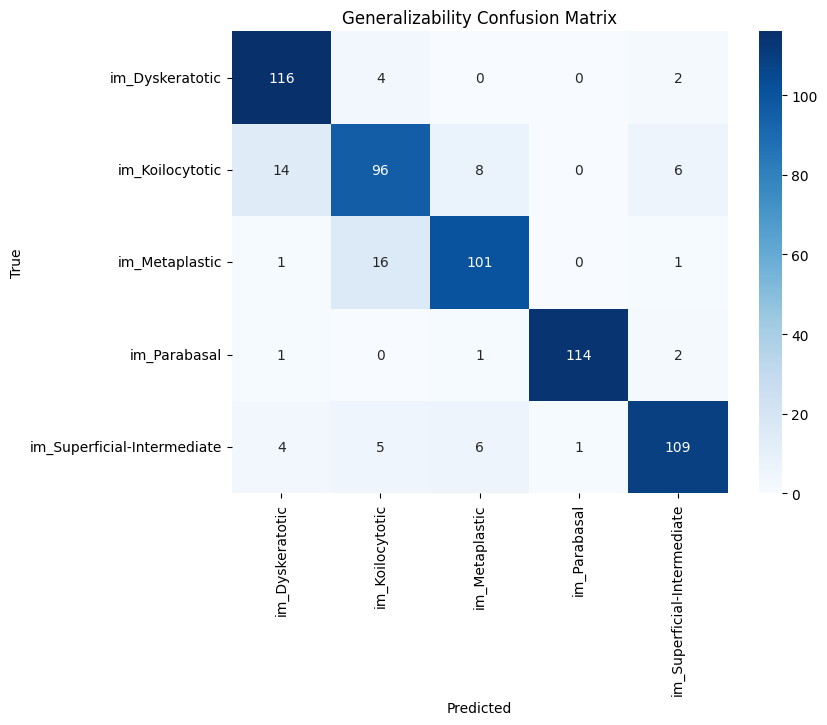

In [32]:
# ==========================================
# Execution: Training & Evaluation (Fixed Typo)
# ==========================================
import copy
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def train_and_evaluate():
    history = {'train_loss': [], 'val_acc': []}
    best_acc = 0.0
    patience = 10
    patience_counter = 0
    
    # Save initial weights
    best_weights = copy.deepcopy(gen_model.state_dict())
    
    print(f"🚀 Starting Training ({num_epochs} Epochs)...")
    
    # --- TRAINING LOOP ---
    for epoch in range(num_epochs):
        gen_model.train()
        running_loss = 0.0
        
        for inputs, labels in tqdm(dataloaders['train'], desc=f"Epoch {epoch+1}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = gen_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        # Validation
        gen_model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = gen_model(inputs)
                _, preds = torch.max(outputs, 1) # Variable is named 'preds'
                total += labels.size(0)
                
                # FIX: Changed 'predicted' to 'preds'
                correct += (preds == labels).sum().item()
        
        epoch_loss = running_loss / len(dataloaders['train'].dataset)
        epoch_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_acc'].append(epoch_acc)
        
        print(f"Epoch {epoch+1}: Loss {epoch_loss:.4f} | Val Acc {epoch_acc:.4f}")
        
        # Early Stopping
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_weights = copy.deepcopy(gen_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("⏹️ Early Stopping Triggered.")
                break
    
    # --- FINAL EVALUATION ON TEST SET ---
    print("\n📝 Evaluating on Unseen Test Set (15%)...")
    gen_model.load_state_dict(best_weights)
    gen_model.eval()
    
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = gen_model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # Metrics
    final_acc = accuracy_score(y_true, y_pred)
    print(f"✅ Final Test Accuracy: {final_acc:.4f}")
    
    # Classification Report
    class_names = list(master_dataset.label_map.keys())
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Generalizability Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Run the function
train_and_evaluate()